In [36]:
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from astropy.io import ascii
from astropy.table import Table, vstack, Column
import sys
import astropy
import pandas as pd
import os

In [37]:
def createCumulatPlotCos(datax, datay, datalabel='', title='', xlabel='', filename='test'):
    fig = plt.figure(figsize=(11,8))
    ax = fig.add_subplot(111)
    
    # get labels
    if datalabel == '':
        datalabel = [''] * len(datax)
    
    # Loop through each dataset and plot it as a step function
    for i in range(len(datax)):
        ax.step(datax[i], datay[i], label=datalabel[i])
    
    # PLOT
    ax.set_title(title, fontsize=24)
    ax.set_ylabel('Frequency', fontsize=18)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_xlim(0, 1.0)
    ax.legend(fontsize=18)
    plt.savefig(filename + '.pdf', dpi=200)

def createCumulatPlotDeg(datax, datay, datalabel='', title='', xlabel='', filename='test'):
    fig = plt.figure(figsize=(11,8))
    ax = fig.add_subplot(111)
    
    # get labels
    if datalabel == '':
        datalabel = [''] * len(datax)
    
    # Loop through each dataset and plot it as a step function
    for i in range(len(datax)):
        ax.step(datax[i], datay[i], label=datalabel[i])
        
    # PLOT
    ax.set_title(title, fontsize=24)
    ax.set_ylabel('Frequency', fontsize=18)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_xlim(0, 90.0)
    ax.legend(fontsize=18)
    plt.savefig(filename + '.pdf', dpi=200)

def makeCumulate(arrayData):
    # sort ascending
    sorted_pas = np.sort(arrayData, axis=None)
    # get length
    number = len(sorted_pas)
    # Compute cumulative fraction (normalized by total number of elements)
    frac_cum = (np.arange(0, number, dtype=np.float32)) / float(number)
    
    return sorted_pas, frac_cum

#### Forplot.txt
- `source` - index
- `Outflow_PA(s)` - assuming center angle, not sure why plural
- `Binary_PA(s)` - assuming separation angle, not sure why plural
- `Delta_PA` - assuming angle between Outflow_PA and Binary_PA, not sure if it should be the smallest angle

<>:88: SyntaxWarning: invalid escape sequence '\D'
<>:96: SyntaxWarning: invalid escape sequence '\D'
<>:88: SyntaxWarning: invalid escape sequence '\D'
<>:96: SyntaxWarning: invalid escape sequence '\D'
/var/folders/41/_gkgvhb94wd4156zplzr4cg00000gn/T/ipykernel_60359/286211559.py:88: SyntaxWarning: invalid escape sequence '\D'
  ], title='Outflow PA vs. Binary PA', xlabel='$\Delta$[Outflow-Binary] (degrees)', filename=os.path.join(output_folder, 'OutflowPA_cumulat_deg'))
/var/folders/41/_gkgvhb94wd4156zplzr4cg00000gn/T/ipykernel_60359/286211559.py:96: SyntaxWarning: invalid escape sequence '\D'
  ], title='Outflow PA vs. Binary PA', xlabel='cos($\Delta$[Outflow-Binary])', filename=os.path.join(output_folder, 'OutflowPA_cumulat_cos'))
/var/folders/41/_gkgvhb94wd4156zplzr4cg00000gn/T/ipykernel_60359/286211559.py:64: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  print(f'{label}: ', stats.anderson_ksamp(

AD Test (Degrees):  Anderson_ksampResult(statistic=np.float64(-0.4498722791532703), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=np.float64(0.25))
AD Test 25% random (Degrees):  Anderson_ksampResult(statistic=np.float64(1.7590322129761504), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.06111702294243863)
AD Test 50% random (Degrees):  Anderson_ksampResult(statistic=np.float64(6.247693025247857), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.0012728179603350796)
AD Test 75% random (Degrees):  Anderson_ksampResult(statistic=np.float64(14.434113739308582), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=np.float64(0.001))
AD Test (Cos):  Anderson_ksampResult(statistic=np.float64(-0.4498722791532703), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=np.float64(0.25))
KS Test (Degrees):  KstestResult(statistic=np.float

/var/folders/41/_gkgvhb94wd4156zplzr4cg00000gn/T/ipykernel_60359/286211559.py:64: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  print(f'{label}: ', stats.anderson_ksamp([observed, model]))


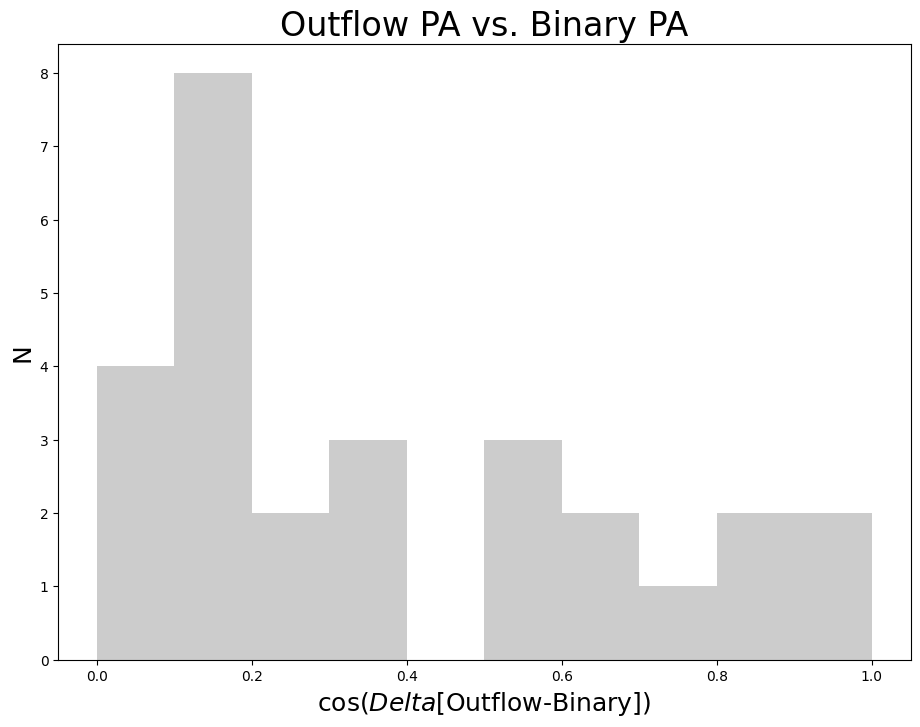

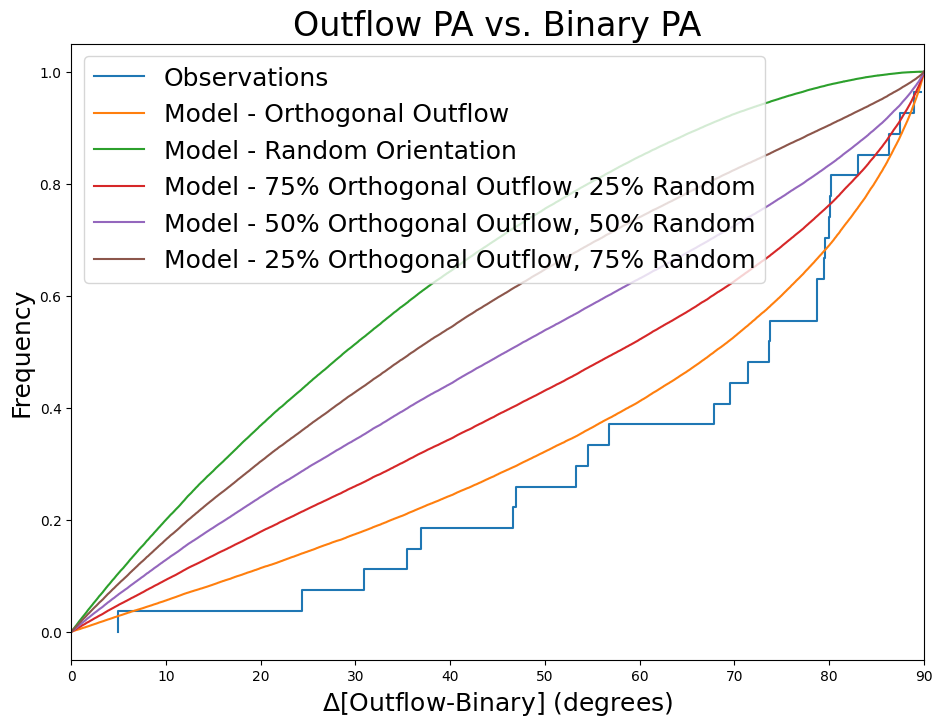

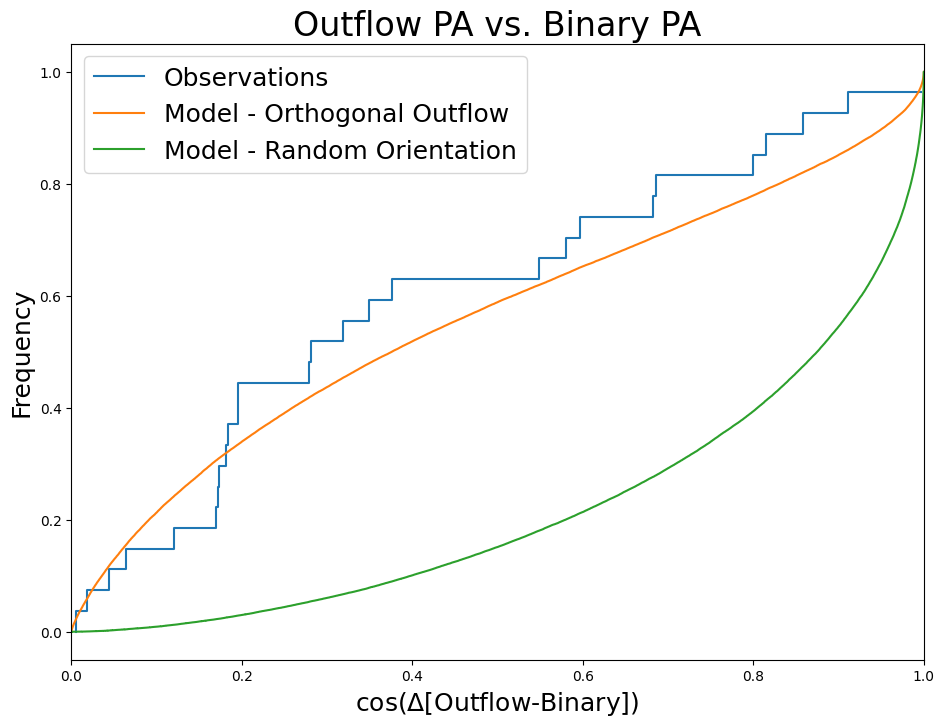

In [38]:
# script options
output_folder = "../results/histogram2"
filename = 'OutflowPA_hist'
output_path = os.path.join(output_folder, filename)

# verify output path exists
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

# load data
data = pd.read_csv('../data/output/outflow_data.csv')

# Create histogram plot
fig, ax1 = plt.subplots(figsize=(11, 8))
cosi = np.cos(data['delta_PA'][:] * np.pi / 180.0)
bins = np.linspace(0, 1.0, 11)
ax1.hist(cosi, bins, fill=True, facecolor='gray', alpha=0.4, histtype='bar', ec='black', linewidth=2.0)
ax1.set_ylabel('N', fontsize=18)
ax1.set_xlabel('cos($Delta$[Outflow-Binary])', fontsize=18)
ax1.set_title('Outflow PA vs. Binary PA', fontsize=24)
plt.savefig(f'{output_path}.pdf')

# Generate cumulative distributions for observed data
paCumulat_cos, frac_paCumulat_cos = makeCumulate(cosi)
paCumulat_deg, frac_paCumulat_deg = makeCumulate(data['delta_PA'][:])

# Generate random position angles and project them
num_samples = 100000
pa = np.random.uniform(0, 90, num_samples) # binary PA
ofa = np.random.uniform(0, 90, num_samples) # random outflow PA offset
inc = np.random.random_sample(num_samples) # inclination
R = np.random.uniform(30.0, 300.0, num_samples) # binary separation distance
projx = R * np.cos(np.radians(pa)) # project binary PA to 2D plane
projy = R * np.sin(np.radians(pa)) * inc # project binary PA to 2D plane
projpa = 90.0 - np.degrees(np.arctan2(projy, projx)) # expected orthogonal outflow PA
projpa_rand = np.abs(ofa - np.degrees(np.arctan2(projy, projx))) # random outflow PA

# Create different percentage-randomized datasets
projpa_25p_rand = np.concatenate((projpa[:75000], projpa_rand[75000:]))
projpa_50p_rand = np.concatenate((projpa[:50000], projpa_rand[50000:]))
projpa_75p_rand = np.concatenate((projpa[:25000], projpa_rand[25000:]))

# Compute cumulative distributions for models
paCumulat_deg_model, frac_paCumulat_deg_model = makeCumulate(projpa)
paCumulat_cos_model, frac_paCumulat_cos_model = makeCumulate(np.cos(np.radians(projpa)))
paCumulat_deg_model_25p_rand, frac_paCumulat_deg_model_25p_rand = makeCumulate(projpa_25p_rand)
paCumulat_cos_model_25p_rand, frac_paCumulat_cos_model_25p_rand = makeCumulate(np.cos(np.radians(projpa_25p_rand)))
paCumulat_deg_model_50p_rand, frac_paCumulat_deg_model_50p_rand = makeCumulate(projpa_50p_rand)
paCumulat_cos_model_50p_rand, frac_paCumulat_cos_model_50p_rand = makeCumulate(np.cos(np.radians(projpa_50p_rand)))
paCumulat_deg_model_75p_rand, frac_paCumulat_deg_model_75p_rand = makeCumulate(projpa_75p_rand)
paCumulat_cos_model_75p_rand, frac_paCumulat_cos_model_75p_rand = makeCumulate(np.cos(np.radians(projpa_75p_rand)))
paCumulat_deg_model_rand, frac_paCumulat_deg_model_rand = makeCumulate(projpa_rand)
paCumulat_cos_model_rand, frac_paCumulat_cos_model_rand = makeCumulate(np.cos(np.radians(projpa_rand)))

# Perform statistical tests
ad_tests = [
    ("AD Test (Degrees)", paCumulat_deg, paCumulat_deg_model),
    ("AD Test 25% random (Degrees)", paCumulat_deg, paCumulat_deg_model_25p_rand),
    ("AD Test 50% random (Degrees)", paCumulat_deg, paCumulat_deg_model_50p_rand),
    ("AD Test 75% random (Degrees)", paCumulat_deg, paCumulat_deg_model_75p_rand),
    ("AD Test (Cos)", paCumulat_cos, paCumulat_cos_model)
]
for label, observed, model in ad_tests:
    print(f'{label}: ', stats.anderson_ksamp([observed, model]))

ks_tests = [
    ("KS Test (Degrees)", paCumulat_deg, paCumulat_deg_model),
    ("KS Test 25% random (Degrees)", paCumulat_deg, paCumulat_deg_model_25p_rand),
    ("KS Test 50% random (Degrees)", paCumulat_deg, paCumulat_deg_model_50p_rand),
    ("KS Test 75% random (Degrees)", paCumulat_deg, paCumulat_deg_model_75p_rand),
    ("KS Test (Cos)", paCumulat_cos, paCumulat_cos_model)
]
for label, observed, model in ks_tests:
    print(f'{label}: ', stats.ks_2samp(observed, model))

# Generate cumulative plots
createCumulatPlotDeg([
    paCumulat_deg, paCumulat_deg_model, paCumulat_deg_model_rand,
    paCumulat_deg_model_25p_rand, paCumulat_deg_model_50p_rand, paCumulat_deg_model_75p_rand
], [
    frac_paCumulat_deg, frac_paCumulat_deg_model, frac_paCumulat_deg_model_rand,
    frac_paCumulat_deg_model_25p_rand, frac_paCumulat_deg_model_50p_rand, frac_paCumulat_deg_model_75p_rand
], datalabel=[
    'Observations', 'Model - Orthogonal Outflow', 'Model - Random Orientation',
    'Model - 75% Orthogonal Outflow, 25% Random',
    'Model - 50% Orthogonal Outflow, 50% Random',
    'Model - 25% Orthogonal Outflow, 75% Random'
], title='Outflow PA vs. Binary PA', xlabel='$\Delta$[Outflow-Binary] (degrees)', filename=os.path.join(output_folder, 'OutflowPA_cumulat_deg'))

createCumulatPlotCos([
    paCumulat_cos, paCumulat_cos_model, paCumulat_cos_model_rand
], [
    frac_paCumulat_cos, frac_paCumulat_cos_model, frac_paCumulat_cos_model_rand
], datalabel=[
    'Observations', 'Model - Orthogonal Outflow', 'Model - Random Orientation'
], title='Outflow PA vs. Binary PA', xlabel='cos($\Delta$[Outflow-Binary])', filename=os.path.join(output_folder, 'OutflowPA_cumulat_cos'))
